# FitScalingLaw

This notebook analyzes the full-batch GD scaling sweep over $p \in \{512,1024,2048,4096\}$ and $\beta \in \{1,\ldots,10\}$. Each beta uses the fitted GD learning-rate transition from `notebooks/pareto_plots.ipynb`:

$$ \mathrm{LR}(\beta)=0.101\left(\frac{0.644}{0.101}\right)^{\frac{1}{1+(\beta/2.27)^{-6.9/\ln 10}}}. $$

The analysis fits $\log(\mathrm{test\ loss}) = a + b\log(p)$ for each $\beta$ and reports the scaling exponent as $-b$.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / 'scripts').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from scripts.process_scaling_law import (
    final_losses,
    fit_scaling_exponents,
    load_scaling_results,
)

run_root = repo_root / 'runs/fit_scaling_law_20260510_184248'
metric = 'test_xent'
plot_dir = run_root
plot_dir.mkdir(parents=True, exist_ok=True)
run_root.resolve()

/tmp/ipykernel_225040/2363694421.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


PosixPath('/n/home07/ssainathan/workplace/temperature_experiments/two_layer_test/runs/fit_scaling_law_20260510_184248')

In [2]:
df = load_scaling_results(run_root)
df.to_csv(run_root / 'scaling_law_results.csv', index=False)

final = final_losses(df, metric)
final.to_csv(run_root / 'scaling_law_final_losses.csv', index=False)
final.head()

,beta,p,lr,step,train_xent,test_xent,train_logit_mse,test_logit_mse
0,1.0,512,0.116909,2000,2.122045,4.909793,1.384818,1.375386
1,1.0,1024,0.116909,2000,3.267504,4.769114,1.166339,1.167593
2,1.0,2048,0.116909,2000,3.950093,4.720519,1.042425,1.045343
3,1.0,4096,0.116909,2000,4.295505,4.676573,0.976856,0.978584
4,2.0,512,0.214378,2000,0.862021,4.739763,1.757721,1.713118


In [3]:
fits = fit_scaling_exponents(final, metric)
fits.to_csv(run_root / 'scaling_law_exponents.csv', index=False)
fits

,beta,metric,slope,scaling_exponent,intercept,r2,n_points
0,1.0,test_xent,-0.022541,0.022541,1.726022,0.915060,4
1,2.0,test_xent,-0.058141,0.058141,1.910897,0.966980,4
2,3.0,test_xent,-0.132015,0.132015,2.331160,0.979943,4
3,4.0,test_xent,-0.180893,0.180893,2.583500,0.989783,4
4,5.0,test_xent,-0.223938,0.223938,2.825261,0.993527,4
5,6.0,test_xent,-0.235690,0.235690,2.862024,0.994241,4
6,7.0,test_xent,-0.246185,0.246185,2.903718,0.994337,4
7,8.0,test_xent,-0.255208,0.255208,2.957363,0.993048,4
8,9.0,test_xent,-0.255738,0.255738,2.941266,0.993026,4
9,10.0,test_xent,-0.255543,0.255543,2.926215,0.994239,4


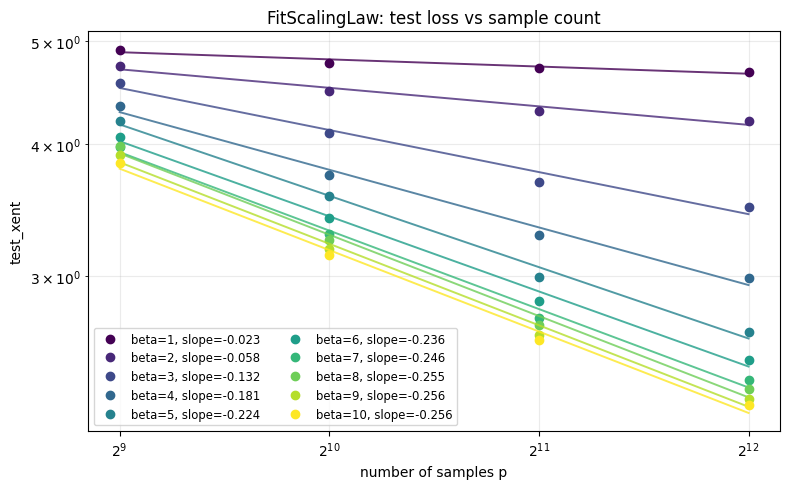

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

cmap = plt.get_cmap('viridis')
betas = sorted(final['beta'].unique())
for color_idx, beta in enumerate(betas):
    group = final[final['beta'] == beta].sort_values('p')
    fit = fits[fits['beta'] == beta].iloc[0]
    color = cmap(color_idx / max(1, len(betas) - 1))
    p_grid = np.geomspace(group['p'].min(), group['p'].max(), 200)
    y_fit = np.exp(fit['intercept']) * p_grid ** fit['slope']
    ax.plot(group['p'], group[metric], marker='o', linestyle='', color=color, label=f"beta={beta:g}, slope={fit['slope']:.3f}")
    ax.plot(p_grid, y_fit, linewidth=1.4, color=color, alpha=0.8)

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('number of samples p')
ax.set_ylabel(metric)
ax.set_title('FitScalingLaw: test loss vs sample count')
ax.grid(True, which='both', alpha=0.25)
ax.legend(fontsize='small', ncols=2)
fig.tight_layout()
fig.savefig(plot_dir / f'fit_scaling_law_{metric}_loglog.png', dpi=180)
plt.show()

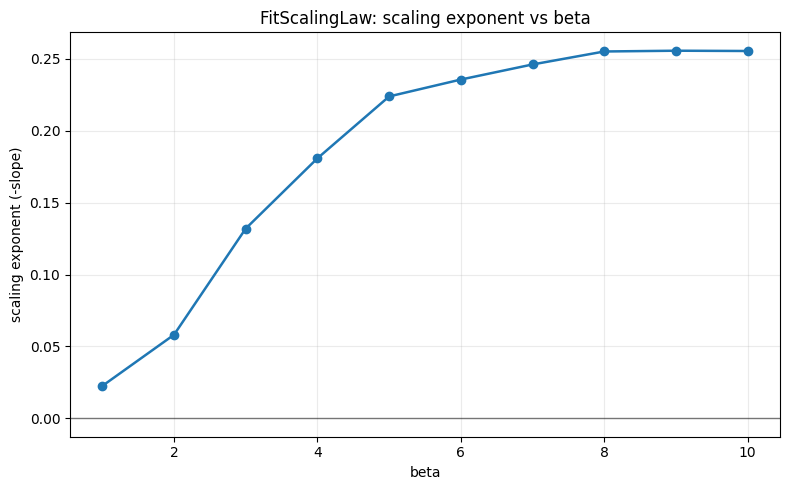

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fits['beta'], fits['scaling_exponent'], marker='o', linewidth=1.8)
ax.axhline(0, color='black', linewidth=1, alpha=0.5)
ax.set_xlabel('beta')
ax.set_ylabel('scaling exponent (-slope)')
ax.set_title('FitScalingLaw: scaling exponent vs beta')
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(plot_dir / f'fit_scaling_law_{metric}_exponent_vs_beta.png', dpi=180)
plt.show()